<a href="https://colab.research.google.com/github/prasad2154/NewVision/blob/main/Practice_Work/House_Price_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    root_mean_squared_error
)

In [ ]:
# load dataset
price=pd.read_csv("/content/house_price_prediction_dataset.csv")

In [ ]:
price[:20]

,Area_sqft,Bedrooms,Bathrooms,House_Age,Floors,Parking,City,Locality_Score,Distance_to_CityCenter_km,Price_INR
0,1412,1,2,17,1,1,Bengaluru,2,17.08,12414561
1,4967,1,2,27,1,0,Pune,4,6.20,34761752
2,717,5,4,34,2,1,Ahmedabad,10,7.32,11066243
3,553,2,3,27,2,2,Bengaluru,4,23.95,7004857
4,1337,1,1,6,2,2,Chennai,1,18.38,10573853
5,1522,4,3,35,2,2,Hyderabad,2,1.62,13825833
6,2870,1,1,6,2,2,Ahmedabad,6,4.49,21893276
7,2216,6,6,4,3,1,Hyderabad,3,11.83,20955791
8,2299,6,6,3,1,0,Delhi,7,7.06,23756748
9,3077,2,3,31,2,3,Bengaluru,5,3.92,25100629


In [ ]:
price.shape

(5000, 10)

In [ ]:
price.columns

Index(['Area_sqft', 'Bedrooms', 'Bathrooms', 'House_Age', 'Floors', 'Parking',
       'City', 'Locality_Score', 'Distance_to_CityCenter_km', 'Price_INR'],
      dtype='object')

In [ ]:
# Input and Output
X=price[['Area_sqft', 'Bedrooms', 'Bathrooms', 'House_Age', 'Floors']]
y=price["Price_INR"]

In [ ]:
price = price.drop_duplicates()

In [ ]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
# Create model
model = LinearRegression()
model

LinearRegression()

In [ ]:
# Train model
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Prediction
y_pred = model.predict(X_test)
y_pred

array([21530998.60615988,  9055470.29605163, 27488951.25636767,
       19016050.0531233 , 34059837.54601629, 23157633.61449311,
       27079977.45621618, 10701821.64671342, 37985984.27581882,
       35551428.23369391, 30396681.65711552, 13433098.65840783,
       15007607.71147018, 26824325.19577125, 27737463.08540726,
       33062086.40848235, 21201243.02671681, 18326143.91331188,
       14843633.38327889, 31007260.66816689, 13461966.07817775,
       12166956.76511221, 24518775.04189874, 29720036.17466504,
       26426166.39300636, 21773443.60000538, 16273087.45523356,
       26357231.44773526, 13565035.69968943, 15330231.43646837,
       24928810.26340244, 10196806.48496879, 34744091.02284119,
       19295964.26349888, 26380645.7812543 , 22446534.32634199,
       23173891.45590668, 12856329.95793215, 39973981.9301879 ,
       33574797.10078972, 21619605.10927785, 27862363.30240068,
       15720571.14478344, 26718327.88966966, 18359336.7586971 ,
       16546988.16903771, 18117752.93580

In [ ]:
print("Train Score :", model.score(X_train, y_train))
print("Test Score  :", model.score(X_test, y_test))

print("R2 Score :", r2_score(y_test, y_pred))
print("MAE      :", mean_absolute_error(y_test, y_pred))
print("MSE      :", mean_squared_error(y_test, y_pred))


Train Score : 0.9692995057398598
Test Score  : 0.9699305381069905
R2 Score : 0.9699305381069905
MAE      : 1180482.8208534531
MSE      : 2246050815936.202


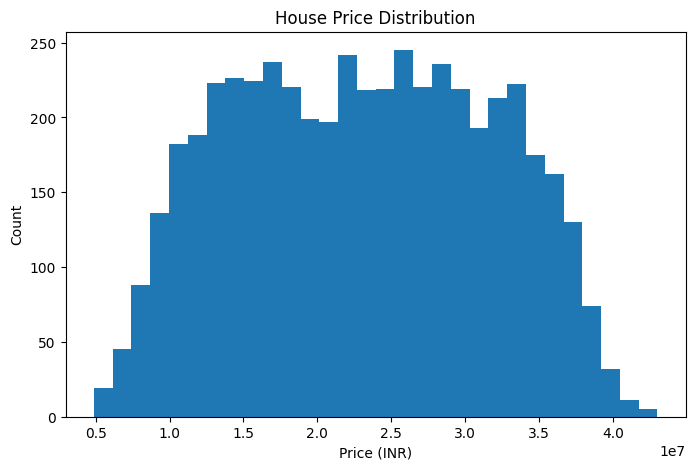

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(price["Price_INR"], bins=30)
plt.title("House Price Distribution")
plt.xlabel("Price (INR)")
plt.ylabel("Count")
plt.show()

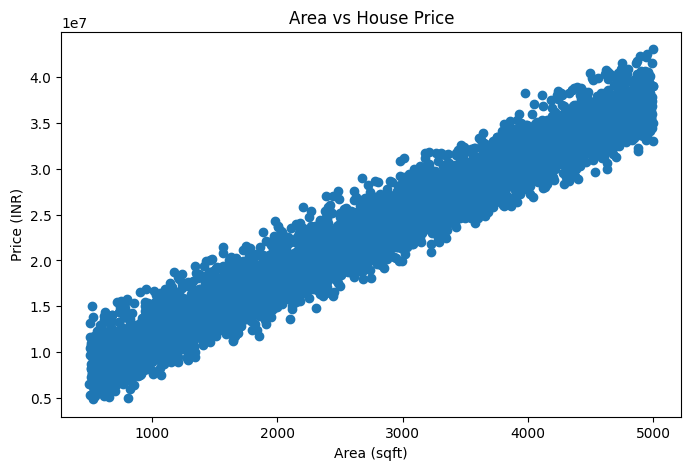

In [ ]:
# Area vs Price (Scatter Plot) ⭐ Most Important
plt.figure(figsize=(8,5))
plt.scatter(price["Area_sqft"], price["Price_INR"])
plt.title("Area vs House Price")
plt.xlabel("Area (sqft)")
plt.ylabel("Price (INR)")
plt.show()

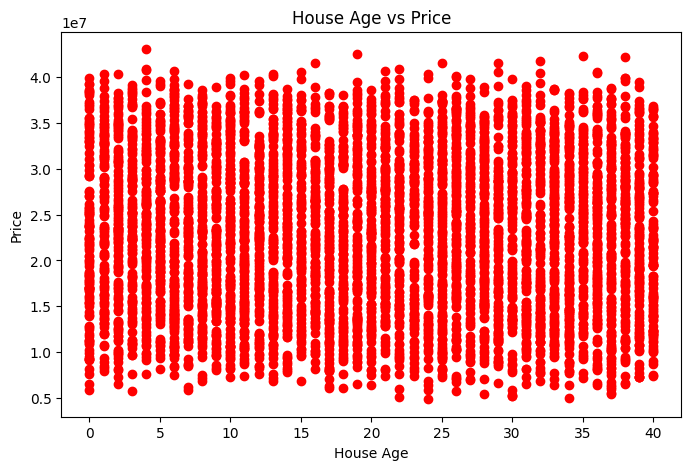

In [ ]:
# House Age vs Price
plt.figure(figsize=(8,5))
plt.scatter(price["House_Age"], price["Price_INR"],color="red")
plt.title("House Age vs Price")
plt.xlabel("House Age")
plt.ylabel("Price")
plt.show()

In [ ]:
# Perform picking
import pickle
pickle.dump(model,open("house.pkl",'wb'))
